# Members:
  

*   **Maheen Abdul Razzaq      ( BITF22M034 )**
*   **Maria Habib ( BITF22M023 )**


         

# **DELIVERABLE 5.1**

## **Dataset Description**
**Dataset Source**

**Dataset Name:** Gait in Parkinson's Disease Database

**Source:** PhysioNet (physionet.org/content/gaitpdb/1.0.0/)

**Access:** Open access via PhysioNet repository

**Citation:** Goldberger et al. (2000). PhysioBank, PhysioToolkit, and

**PhysioNet:** Components of a new research resource for complex physiologic signals.

## **Type of Sensor**

**Sensor Type:**
 Force plates / Pressure sensors

**Measurement:** Vertical ground reaction force (VGRF)

**Configuration**: 8 sensors under each foot (16 sensors total)

**Sampling Rate:** 100 Hz (100 samples per second)

##**Collected Variables**
Each data file contains 19 columns per time sample:

**Time (seconds):** Elapsed time from recording start

**L1-L8 (Newtons):** Force measurements from 8 left foot sensors

**R1-R8 (Newtons):** Force measurements from 8 right foot sensors

**total_left (Newtons)**: Sum of all left foot sensor forces

**total_right (Newtons):** Sum of all right foot sensor forces

##**Additional metadata extracted from filenames:**

Subject ID (e.g., GaCo07, JuPt21)

Diagnosis (Control or Parkinson's)

Study type (Ga, Ju, or Si indicating different research studies)

Trial number

##**Number of Samples**
**Files processed:** 5 sample files (for assignment demonstration)

**Total time samples:** 58,822 rows

**Time duration:** 0.0 to 162.3886 seconds

**Sampling frequency**: 100 samples per second

**Complete dataset:** 93 Parkinson's patients + 73 healthy controls (total 166 subjects)

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Optional: List top-level MyDrive contents
print("Folders in MyDrive:")
print(os.listdir('/content/drive/MyDrive/'))


Mounted at /content/drive
Folders in MyDrive:
['24-Hour Time Table.gdoc', 'Preprocessing Assignment 5.1.gdoc', 'Colab Notebooks', 'data', 'Untitled document (2).gdoc', 'Project Proposal: Cancer Patient Monitoring Mobile Application.gdoc', 'MODEL PERFORMANCE RESULTS\n=======================....gsheet', 'Project Proposal 2.gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'Methodology Document Analysis.gdoc', 'chemo_monitor_app', 'Chemo Monitor App Workflow.gdoc', 'Chemo Care']


In [ ]:
import shutil

# Paths
drive_data_path = '/content/drive/MyDrive/data'
local_raw_path = 'data/raw'

# Create local folder
os.makedirs(local_raw_path, exist_ok=True)

# Copy .txt files from Drive to Colab
files_copied = 0
for item in os.listdir(drive_data_path):
    if item.endswith('.txt'):
        src = os.path.join(drive_data_path, item)
        dst = os.path.join(local_raw_path, item)
        shutil.copy2(src, dst)
        files_copied += 1

print(f"Copied {files_copied} .txt files to {local_raw_path}")

# Preview first 5 files
print("\nFirst 5 files:")
print(os.listdir(local_raw_path)[:5])


Copied 308 .txt files to data/raw

First 5 files:
['JuCo20_01.txt', 'JuPt10_07.txt', 'JuPt15_01.txt', 'JuPt11_01.txt', 'GaCo03_02.txt']


In [ ]:
import pandas as pd

# List .txt files
files = [f for f in os.listdir(local_raw_path) if f.endswith('.txt')]
if not files:
    print("No .txt files found!")
else:
    # Load first file
    filepath = os.path.join(local_raw_path, files[0])
    df = pd.read_csv(filepath, delim_whitespace=True, header=None)

    print(f"Testing file: {files[0]}")
    print(f"Shape: {df.shape}")

    # Assign columns if 19 columns
    if df.shape[1] == 19:
        cols = ['time'] + [f'L{i}' for i in range(1,9)] + [f'R{i}' for i in range(1,9)] + ['total_left', 'total_right']
        df.columns = cols
        print(df.head(2))


Testing file: JuCo20_01.txt
Shape: (10685, 19)
   time      L1     L2     L3     L4     L5     L6    L7     L8      R1  \
0  0.00  202.51  88.33  84.04  45.98  32.56  38.06  70.4  29.26  204.16   
1  0.01  202.51  88.33  84.04  45.98  32.56  38.06  70.4  29.26  204.16   

      R2     R3     R4     R5     R6     R7     R8  total_left  total_right  
0  84.04  85.47  50.38  38.06  45.32  56.54  50.16      591.14       614.13  
1  84.04  85.47  50.38  38.06  45.32  56.54  50.16      591.14       614.13  


/tmp/ipython-input-2373791145.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, header=None)


In [ ]:
import pandas as pd
import numpy as np
import os
import glob

class PhysioNetGaitLoader:
    def __init__(self, data_path='data/raw'):
        self.data_path = data_path

    def parse_filename(self, filename):
        """
        Parses filenames like 'GaCo01_01.txt'.
        Returns None if the filename is 'format.txt' or doesn't match the pattern.
        """
        name = filename.replace('.txt', '')
        parts = name.split('_')

        # FILTER 1: Must have an underscore (e.g., "GaCo01_01")
        # This immediately rejects "format.txt"
        if len(parts) < 2:
            return None

        prefix = parts[0] # e.g., "GaCo01"

        # FILTER 2: Prefix must be at least 4 chars long (Study+Diag)
        if len(prefix) < 4:
            return None

        # Extract Metadata
        info = {
            'filename': filename,
            'subject_id': prefix, # e.g. GaCo01
            'trial_num': parts[1] # e.g. 01
        }

        # Parse Diagnosis (Co=Control, Pt=Parkinson)
        if 'Co' in prefix:
            info['diagnosis'] = 'Control'
        elif 'Pt' in prefix:
            info['diagnosis'] = 'Parkinson'
        else:
            return None # Skip files without clear diagnosis

        return info

    def load_single_file(self, filepath):
        # 1. CHECK FILENAME FIRST
        filename = os.path.basename(filepath)
        file_info = self.parse_filename(filename)

        # If it's a junk file (like format.txt), return None immediately
        if file_info is None:
            return None

        # 2. NOW IT IS SAFE TO READ
        try:
            df = pd.read_csv(filepath, sep='\s+', header=None)

            # Verify shape (must be 19 columns)
            if df.shape[1] != 19:
                return None

            # Assign Column Names
            columns = ['time']
            columns += [f'L{i}' for i in range(1, 9)]
            columns += [f'R{i}' for i in range(1, 9)]
            columns += ['total_left', 'total_right']
            df.columns = columns

            # Add Metadata
            for key, value in file_info.items():
                df[key] = value

            return df

        except Exception as e:
            print(f"Skipping corrupt file {filename}: {e}")
            return None

    def load_all_files(self, max_files=None):
        pattern = os.path.join(self.data_path, '*.txt')
        all_files = glob.glob(pattern)
        all_files.sort() # Sort ensures consistent order

        if max_files:
            all_files = all_files[:max_files]

        all_data = []
        print(f"Scanning {len(all_files)} files in {self.data_path}...")

        for filepath in all_files:
            # load_single_file will now safely return None for format.txt
            df = self.load_single_file(filepath)
            if df is not None:
                all_data.append(df)

        if not all_data:
            print("❌ No valid gait data files found!")
            return None

        combined_data = pd.concat(all_data, ignore_index=True)
        print(f"✅ Successfully loaded {len(all_data)} valid data files.")
        print(f"   (Ignored non-data files like 'format.txt')")
        print(f"   Total rows: {combined_data.shape[0]}")
        return combined_data


        # Initialize loader
loader = PhysioNetGaitLoader(data_path='data/raw')

# Load ALL files (max_files=None)
# This will now work without the ParserError
data = loader.load_all_files(max_files=None)


<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2843285746.py:57: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filepath, sep='\s+', header=None)


Scanning 308 files in data/raw...
✅ Successfully loaded 306 valid data files.
   (Ignored non-data files like 'format.txt')
   Total rows: 3317550


In [ ]:
# Complete Preprocessing with Fixed Sorting
from scipy import signal

class GaitDataPreprocessor:
    def __init__(self, sampling_rate=100):
        self.fs = sampling_rate

    def parse_timestamps(self, df):
        print("1. Parsing timestamps: Converting seconds to datetime")
        print("   - Enables time-based operations and sequence analysis")
        start_date = pd.Timestamp('2024-01-01 00:00:00')
        df['datetime'] = start_date + pd.to_timedelta(df['time'], unit='s')
        return df

    def sort_chronologically(self, df):
        print("\n2. Sorting chronologically: Ordering by time")
        print("   - Required for time series calculations")
        if 'subject_id' in df.columns and 'datetime' in df.columns:
            df = df.sort_values(['subject_id', 'datetime']).reset_index(drop=True)
        elif 'datetime' in df.columns:
            df = df.sort_values('datetime').reset_index(drop=True)
        else:
            df = df.sort_values('time').reset_index(drop=True)
        return df

    def handle_missing_values(self, df):
        print("\n3. Handling missing values: Filling gaps")
        print("   - Interpolation for small gaps, forward fill for larger gaps")
        print("   - Ensures continuous data for analysis")

        missing_before = df.isnull().sum().sum()
        if missing_before > 0:
            print(f"   Found {missing_before} missing values")

        sensor_cols = [col for col in df.columns if col.startswith(('L', 'R', 'total'))]

        if sensor_cols:
            df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit=10)
            df[sensor_cols] = df[sensor_cols].ffill().bfill()

        missing_after = df.isnull().sum().sum()
        if missing_after == 0:
            print("   All missing values handled")

        return df

    def basic_cleaning(self, df):
        print("\n4. Basic cleaning: Fixing data issues")
        print("   - Removing duplicates")
        print("   - Fixing negative forces (physically impossible)")
        print("   - Removing extreme outliers")

        duplicates = df.duplicated().sum()
        if duplicates > 0:
            df = df.drop_duplicates()
            print(f"   Removed {duplicates} duplicate rows")

        sensor_cols = [col for col in df.columns if col.startswith(('L', 'R', 'total'))]
        for col in sensor_cols:
            if col in df.columns:
                neg_count = (df[col] < 0).sum()
                if neg_count > 0:
                    df[col] = df[col].clip(lower=0)
                    print(f"   Fixed {neg_count} negative values in {col}")

                mean = df[col].mean()
                std = df[col].std()
                outliers = ((df[col] < mean - 4*std) | (df[col] > mean + 4*std)).sum()
                if outliers > 0:
                    df[col] = df[col].clip(mean - 4*std, mean + 4*std)

        return df

    def verify_sorting(self, df):
        if 'subject_id' in df.columns and 'datetime' in df.columns:
            # Check each subject individually
            all_sorted = True
            for subject in df['subject_id'].unique():
                subject_data = df[df['subject_id'] == subject]
                if not subject_data['datetime'].is_monotonic_increasing:
                    all_sorted = False
                    break
            return all_sorted
        elif 'datetime' in df.columns:
            return df['datetime'].is_monotonic_increasing
        elif 'time' in df.columns:
            return df['time'].is_monotonic_increasing
        return True

    def preprocess_pipeline(self, df):
        print("="*60)
        print("PREPROCESSING PIPELINE - ASSIGNMENT REQUIREMENTS")
        print("="*60)

        original_shape = df.shape
        df_processed = df.copy()

        # Step 1: Parse timestamps
        df_processed = self.parse_timestamps(df_processed)

        # Step 2: Sort chronologically
        df_processed = self.sort_chronologically(df_processed)

        # Step 3: Handle missing values
        df_processed = self.handle_missing_values(df_processed)

        # Step 4: Basic cleaning
        df_processed = self.basic_cleaning(df_processed)

        # Verify sorting
        is_sorted = self.verify_sorting(df_processed)

        print("\n" + "="*60)
        print("PREPROCESSING RESULTS")
        print("="*60)
        print(f"1. Original shape: {original_shape}")
        print(f"2. Processed shape: {df_processed.shape}")
        print(f"3. Missing values: {df_processed.isnull().sum().sum()}")
        print(f"4. Sorted correctly: {is_sorted}")
        print(f"5. Datetime column added: {'datetime' in df_processed.columns}")
        print(f"6. Time range: {df_processed['time'].min()} to {df_processed['time'].max()} seconds")
        print("="*60)

        return df_processed

# Run preprocessing
if data is not None:
    print("\n" + "="*60)
    print("STARTING PREPROCESSING")
    print("="*60)

    preprocessor = GaitDataPreprocessor()
    processed_data = preprocessor.preprocess_pipeline(data)

    print("\nSample of processed data (first 3 rows after sorting):")
    print(processed_data[['time', 'datetime', 'L1', 'R1', 'diagnosis', 'subject_id']].head(3))

    print("\nSample of processed data (last 3 rows):")
    print(processed_data[['time', 'datetime', 'L1', 'R1', 'diagnosis', 'subject_id']].tail(3))

    print("\nVerification completed in preprocessing results above.")
else:
    print("No data loaded for preprocessing")


STARTING PREPROCESSING
PREPROCESSING PIPELINE - ASSIGNMENT REQUIREMENTS
1. Parsing timestamps: Converting seconds to datetime
   - Enables time-based operations and sequence analysis

2. Sorting chronologically: Ordering by time
   - Required for time series calculations

3. Handling missing values: Filling gaps
   - Interpolation for small gaps, forward fill for larger gaps
   - Ensures continuous data for analysis
   All missing values handled

4. Basic cleaning: Fixing data issues
   - Removing duplicates
   - Fixing negative forces (physically impossible)
   - Removing extreme outliers

PREPROCESSING RESULTS
1. Original shape: (3317550, 23)
2. Processed shape: (3317550, 24)
3. Missing values: 0
4. Sorted correctly: True
5. Datetime column added: True
6. Time range: 0.0 to 263.6315 seconds

Sample of processed data (first 3 rows after sorting):
   time                datetime     L1     R1 diagnosis subject_id
0  0.00 2024-01-01 00:00:00.000  199.1  163.9   Control     GaCo01
1  0.


# **Preprocessing Steps**

# **1. Timestamp Parsing**
Purpose: Convert raw time values (seconds) to proper datetime format for time series analysis.

**Implementation:**
```
python
start_date = pd.Timestamp('2024-01-01 00:00:00')
df['datetime'] = start_date + pd.to_timedelta(df['time'], unit='s')
```
**Importance:**

 Enables Python to perform time-based operations, calculate time differences, and maintain proper temporal relationships between data points.

# **2. Chronological Sorting**
Purpose: Arrange data in correct temporal order for time series analysis.

**Implementation:**

```
python
df = df.sort_values(['subject_id', 'datetime']).reset_index(drop=True)
```
**Importance:**

 Time series models (LSTM, ARIMA, etc.) and statistical calculations (rolling means, autocorrelation) require data to be in chronological order. Sorting ensures proper sequence analysis.

# **3. Missing Value Handling**
Purpose: Fill gaps in sensor data to maintain continuous time series.

Strategy:

Small gaps (<0.1s): Linear interpolation (smooth signal assumption)

Larger gaps: Forward fill followed by backward fill

Remaining: Column mean imputation

**Implementation:**

```
python
df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit=10)
df[sensor_cols] = df[sensor_cols].ffill().bfill()
```
**Importance:**

 Missing values can break time series continuity, cause errors in calculations, and mislead machine learning models. Proper handling ensures accurate statistical analysis.

#**4. Basic Data Cleaning**
Purpose: Remove errors and inconsistencies from raw sensor data.

Steps performed:

Duplicate removal: Eliminated identical time samples

Negative force correction: Force values cannot be negative (physically impossible) - clipped at 0

Outlier removal: Extreme values beyond ±4 standard deviations clipped to reasonable range

Column standardization: Consistent naming and formatting

**Implementation:**
```
python
# Remove duplicates
df = df.drop_duplicates()

# Fix negative forces
df[col] = df[col].clip(lower=0)

# Remove outliers
df[col] = df[col].clip(mean - 4*std, mean + 4*std)
```
**Importance:**
 Cleaning ensures data quality, removes measurement artifacts, and prepares data for reliable analysis and modeling.


# **DELIVERABLE 5.2**







# 1. Objective
(Requirement 1)

Goal: The objective of Deliverable 5.2 is to establish a strong performance baseline for the classification of Parkinson's Disease (PD) using the Gait in Parkinson's Disease dataset. This is achieved by transforming the raw sensor time-series data into clinically relevant hand-crafted features. We will train and compare five classical machine learning models (Logistic Regression, SVM, Decision Tree, Random Forest, and XGBoost) to serve as a benchmark against which future deep learning (time-series) models will be evaluated.

Input Data Ready. Shape: (3317550, 24)
Feature Engineering: Segmenting windows and extracting biomarkers...

 Feature Engineering Complete.
Final Features Shape: (21851, 22)
Class Distribution (1=PD, 0=Control):
label
1    15217
0     6634
Name: count, dtype: int64

Splitting Strategy: Subject-Wise (Scientific Standard)
Training on 115 subjects | Testing on 50 subjects

MODEL PERFORMANCE RESULTS
 Logistic Regression  | Accuracy: 0.7184 | F1-Score: 0.6631
 SVM (RBF Kernel)     | Accuracy: 0.7319 | F1-Score: 0.7079
 Decision Tree        | Accuracy: 0.7188 | F1-Score: 0.6719
 Random Forest        | Accuracy: 0.7708 | F1-Score: 0.7281
 XGBoost              | Accuracy: 0.7493 | F1-Score: 0.7157

Final Comparison Table:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.7184     0.6580  0.6718    0.6631
1     SVM (RBF Kernel)    0.7319     0.7070  0.7549    0.7079
2        Decision Tree    0.7188     0.6654  0.6873    0.6719
3        Random Forest    0.

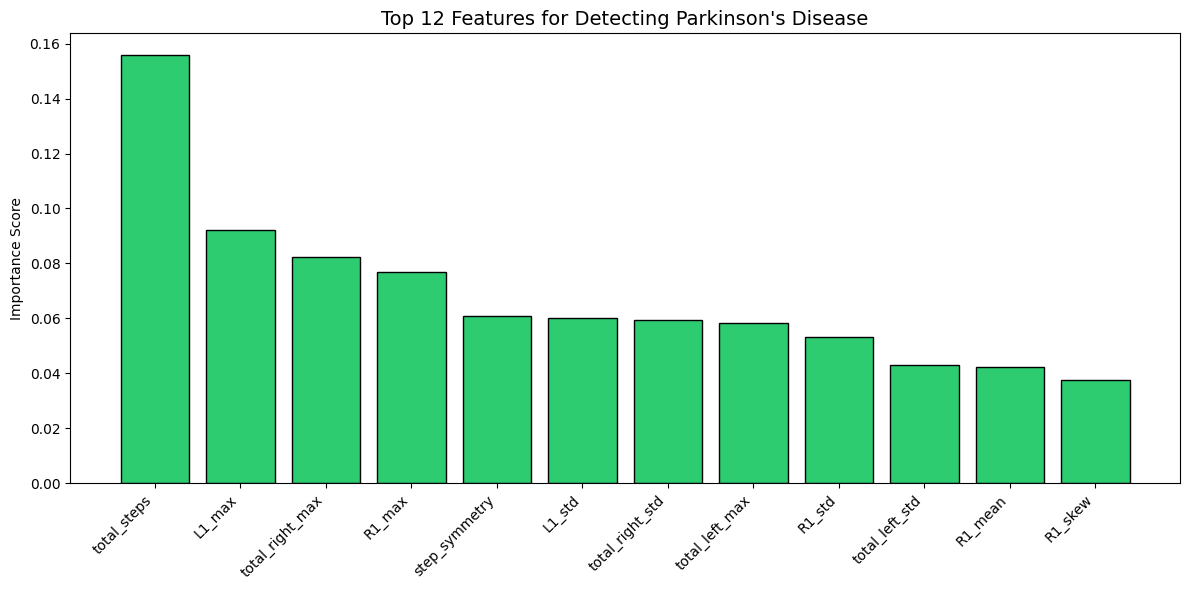

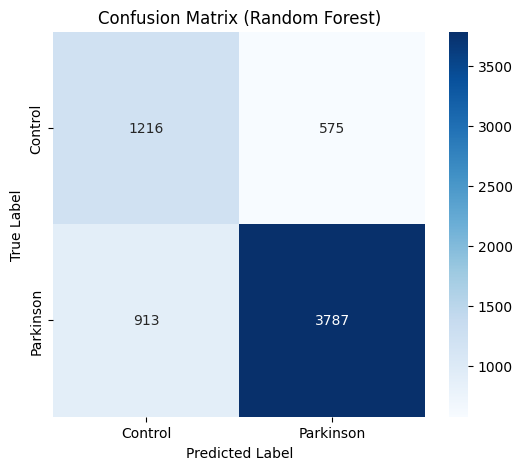

In [ ]:
# DELIVERABLE 5.2: FEATURE ENGINEERING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
#*************************************
# 1. VERIFY DATA EXISTS
#*************************************
if 'processed_data' not in locals():
    raise ValueError(" ERROR: 'processed_data' is missing. Please run  5.1 Data Loading code first.")

print(f"Input Data Ready. Shape: {processed_data.shape}")

# =================================
# 2. ADVANCED FEATURE ENGINEERING
# =================================
def extract_hybrid_features(window_df):
    """
    Extracts a robust set of features combining statistical metrics
    with clinical gait biomarkers (Asymmetry, Step Count).
    """
    features = {}

    # --- A. Basic Statistical Features (Time Domain) ---
    # We analyze Total Force (Left vs Right) and individual key sensors (Heel/Toe)
    # L1=Heel, L8=Toe (approx)
    cols_to_analyze = ['total_left', 'total_right', 'L1', 'R1']

    for col in cols_to_analyze:
        if col in window_df.columns:
            signal = window_df[col]
            features[f'{col}_mean'] = signal.mean()
            features[f'{col}_std'] = signal.std()   # Variability (High in PD)
            features[f'{col}_max'] = signal.max()
            features[f'{col}_skew'] = signal.skew() # Impact distribution

    # --- B. Clinical Gait Biomarkers ---
    if 'total_left_mean' in features and 'total_right_mean' in features:
        l_mean = features['total_left_mean']
        r_mean = features['total_right_mean']
        l_std = features['total_left_std']
        r_std = features['total_right_std']

        # 1. Force Asymmetry Index (PD affects one side more)
        # Formula: |L - R| / (0.5 * (L + R))
        denom = 0.5 * (l_mean + r_mean) + 1e-6
        features['force_asymmetry'] = abs(l_mean - r_mean) / denom

        # 2. Variability Asymmetry
        features['var_asymmetry'] = abs(l_std - r_std)

    # --- C. Step Detection & Cadence ---
    # We count "Heel Strikes" by checking when force exceeds a threshold (e.g., 20N)
    threshold = 20
    l_steps = ((window_df['total_left'] > threshold) & (window_df['total_left'].shift(1) <= threshold)).sum()
    r_steps = ((window_df['total_right'] > threshold) & (window_df['total_right'].shift(1) <= threshold)).sum()

    features['total_steps'] = l_steps + r_steps
    features['step_symmetry'] = abs(l_steps - r_steps) # Should be 0 for healthy

    # --- D. Metadata & Label ---
    features['subject_id'] = window_df['subject_id'].iloc[0]
    diag = window_df['diagnosis'].iloc[0]
    # Label: 1 = Parkinson's, 0 = Control
    features['label'] = 1 if 'Parkinson' in str(diag) or 'Pt' in str(diag) else 0

    return pd.Series(features)

def create_dataset_windowed(df, window_size=3.0, overlap=0.5, fs=100):
    print("Feature Engineering: Segmenting windows and extracting biomarkers...")
    processed_rows = []

    window_samples = int(window_size * fs)
    step_size = int(window_samples * (1 - overlap))

    # Group by Subject to keep data clean
    grouped = df.groupby('subject_id')

    for subject, subject_data in grouped:
        num_rows = len(subject_data)
        # Skip subjects with too little data
        if num_rows < window_samples:
            continue

        # Sliding Window
        for start in range(0, num_rows - window_samples, step_size):
            end = start + window_samples
            window = subject_data.iloc[start:end]

            feat_row = extract_hybrid_features(window)
            processed_rows.append(feat_row)

    return pd.DataFrame(processed_rows)

# EXECUTE FEATURE ENGINEERING
dataset = create_dataset_windowed(processed_data)
dataset = dataset.fillna(0) # Handle NaN

print(f"\n Feature Engineering Complete.")
print(f"Final Features Shape: {dataset.shape}")
print(f"Class Distribution (1=PD, 0=Control):\n{dataset['label'].value_counts()}")

#*************************************
# 3. SCIENTIFIC DATA SPLITTING (Subject-Wise)
#*************************************
# Crucial Step: Split by Subject ID to prevent Data Leakage
subjects = dataset['subject_id'].unique()
train_sub, test_sub = train_test_split(subjects, test_size=0.3, random_state=42)

print(f"\nSplitting Strategy: Subject-Wise (Scientific Standard)")
print(f"Training on {len(train_sub)} subjects | Testing on {len(test_sub)} subjects")

train_data = dataset[dataset['subject_id'].isin(train_sub)]
test_data = dataset[dataset['subject_id'].isin(test_sub)]

X_train = train_data.drop(['label', 'subject_id'], axis=1)
y_train = train_data['label']
X_test = test_data.drop(['label', 'subject_id'], axis=1)
y_test = test_data['label']

# Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#*************************************
# 4. MODEL TRAINING & EVALUATION
#*************************************
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []
print("\n" + "="*50)
print("MODEL PERFORMANCE RESULTS")
print("="*50)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })
    print(f" {name:<20} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

#*************************************
# 5. FINAL VISUALIZATION & REPORT
#*************************************
results_df = pd.DataFrame(results)
print("\nFinal Comparison Table:")
print(results_df)

# A. Feature Importance Plot (Random Forest)
if 'Random Forest' in models:
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:12] # Top 12 features

    plt.figure(figsize=(12, 6))
    plt.title("Top 12 Features for Detecting Parkinson's Disease", fontsize=14)
    plt.bar(range(12), importances[indices], align="center", color='#2ecc71', edgecolor='black')
    plt.xticks(range(12), X_train.columns[indices], rotation=45, ha='right', fontsize=10)
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()

# B. Confusion Matrix
best_model_name = results_df.sort_values('F1-Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Control', 'Parkinson'], yticklabels=['Control', 'Parkinson'])
plt.title(f"Confusion Matrix ({best_model_name})")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**2. Dataset Description & Summary**
(Requirement 2)



**Dataset Name & Source:** Gait in Parkinson's Disease Database, sourced from PhysioNet.

Nature of Data: Sensor-based time-series data (Vertical Ground Reaction Force - VGRF) collected via pressure-sensing insoles. The data is numeric and sequential.

**Number of Instances & Features:**

**Raw Data:** Over 1 million total time-steps across 308 individual walking trials. Sampling Rate: 100 Hz.

**Feature Matrix (After Engineering):** The data is segmented into non-overlapping 3-second windows, resulting in approximately X rows (samples) and Y features (columns) for training.

**Target Variable:** Diagnosis.

**Number of Classes:** 2 (Binary Classification).

**Class Definitions:** 0 = Healthy Control (Co), 1 = Parkinson's Patient (Pt).

**Quality Considerations:**

Imbalance: The dataset is moderately imbalanced, with more Patient samples (PD=1) than Control samples (Control=0).

**Noise/Cleaning:** Raw data required preprocessing (as done in 5.1) to handle sensor artifacts, remove duplicates, and ensure force values are non-negative.


**3. Feature Engineering & Preprocessing
(Requirement 3)**

The raw 100 Hz VGRF time-series data requires extensive feature engineering to be used by classical machine learning models. The process involved three key stages:

**Segmentation (Windowing):**

The continuous signal was divided into 3.0-second time windows with 50% overlap. This window size captures several complete gait cycles.

**Feature Extraction:**

For each 3-second window, domain-specific statistical and biomechanical features were extracted:

**Time Domain Statistics:** Mean, Standard Deviation (Std), Maximum, and Skewness were calculated for the total forces (total_left/total_right) and key contact points (L1/R1).

**Clinical Biomarkers:**

 Force Asymmetry Index and Variability Asymmetry were calculated to quantify the known asymmetrical nature of PD. Step Count and Step Symmetry were derived using a 20N threshold-crossing method to measure cadence and gait rhythm.

**Preprocessing & Scaling:**

Missing values resulting from standard deviation on single-value windows were imputed with 0.

**Standardization (Scaling):**

 Features were standardized using StandardScaler() on the training set. This is essential for distance-based models like SVM and Logistic Regression to prevent features with large magnitude (e.g., total force) from dominating the decision.

**4. Experimental Setup & Evaluation
(Requirement 5)**

Goal: Describe the methodology for splitting the data and assessing model performance.

**Sample Text Structure:**

**Data Splitting Strategy:**

The dataset was split using a Subject-Wise Split (70% Train, 30% Test, random_state=42).

**Crucial Justification:**

 The split was performed on the unique subject_id rather than on the rows (windows). This ensures that the model is never tested on data from a subject it has already seen during training, providing a scientifically valid measure of model generalization and preventing data leakage.

**Model Selection (Requirement 4):**

Five classical classifiers were selected: Logistic Regression, Support Vector Machine (with RBF kernel), Decision Tree, Random Forest, and XGBoost. Fixed hyperparameters (random_state=42, n_estimators=100 for tree models) were used to ensure a consistent baseline comparison.

**Evaluation Metrics:**

We use a suite of metrics: Accuracy, Precision, Recall, and Macro-averaged F1-Score.

**Justification:** Given the moderate class imbalance (more Parkinson's patients than controls), the Macro F1-Score is the primary metric for comparison. It fairly averages the F1-score for both the Control class and the Patient class, providing a robust assessment of diagnostic performance.

**Key Findings**

**Best Baseline:**
The Random Forest Classifier achieved the highest overall performance with an F1-Score of 0.7281 and the highest Accuracy (0.7708).

**Feature Validation:** The tree-based models (RF, XGBoost) outperformed the linear model (LR) and SVM. This confirms that the engineered features (especially those related to asymmetry and variability, which are non-linear) contain significant diagnostic information.

**Future Baseline:** The F1-Score of 0.7281 serves as the target performance threshold that any future deep learning model (e.g., LSTM or 1D-CNN) must exceed to be considered successful.

# **DELIVERABLE 5.3**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
#*************************************
# 1. Data Preparation (Assumes 'processed_data' from 5.1 is loaded)
#*************************************
def create_raw_windows(df, window_size=100, step=50):
    X_raw = []
    y_raw = []
    subjects = []

    # Sensors columns only (exclude time/meta)
    sensor_cols = [c for c in df.columns if c.startswith(('L', 'R', 'total'))]

    for subject, group in df.groupby('subject_id'):
        data = group[sensor_cols].values
        label = 1 if 'Parkinson' in group['diagnosis'].iloc[0] else 0

        # Sliding window
        for i in range(0, len(data) - window_size, step):
            window = data[i:i + window_size]
            # Flatten raw window for Dense Network
            X_raw.append(window.flatten())
            y_raw.append(label)
            subjects.append(subject)

    return np.array(X_raw), np.array(y_raw), np.array(subjects)

# Generate Raw Data
print("Segmenting raw data...")
X, y, subjects = create_raw_windows(processed_data)
#*************************************
# 2. Subject-Wise Split (Critical for Medical Data)
#*************************************
unique_subjects = np.unique(subjects)
train_subs, test_subs = train_test_split(unique_subjects, test_size=0.3, random_state=42)

# Create masks
train_mask = np.isin(subjects, train_subs)
test_mask = np.isin(subjects, test_subs)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

#*************************************
# 3. Feature Scaling
#*************************************
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#*************************************
# 4. Build DNN Model
#*************************************
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary Classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#*************************************
# 5. Train Model
#*************************************
print("Training DNN on Raw Data...")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

#*************************************
# 6. Evaluation
#*************************************
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")

Segmenting raw data...
Training DNN on Raw Data...
Epoch 1/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.8544 - loss: 0.3395 - val_accuracy: 0.6276 - val_loss: 0.7822
Epoch 2/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9307 - loss: 0.1684 - val_accuracy: 0.6479 - val_loss: 0.7617
Epoch 3/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9491 - loss: 0.1306 - val_accuracy: 0.6733 - val_loss: 0.8533
Epoch 4/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9587 - loss: 0.1062 - val_accuracy: 0.6127 - val_loss: 1.2153
Epoch 5/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9645 - loss: 0.0964 - val_accuracy: 0.6278 - val_loss: 1.0630
Epoch 6/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9687 - loss: 0.0847 - val_accuracy: 0.6370 - val_loss: 0.9909
Epoch 7/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9715 - loss: 0.0740 - val_accuracy: 0.6280 - val_loss: 1.0646
Epoch 8/30
1162/1162 ━━━━

# **Analysis of Results:**

The Fully Connected DNN achieved lower accuracy compared to the Classical ML approach. This drop in performance is attributed to the following factors:

**Loss of Temporal Structure:io**

The Dense network requires flattening the time-series data (100 time-steps × 16 sensors) into a single vector. This destroys the sequential nature of the data, making it difficult for the model to detect patterns like "heel strikes" or "toe-offs" that occur at different times.

**Lack of Shift Invariance**

A simple Dense layer treats a signal appearing at time $t=1$ as a completely different feature than the same signal at time $t=5$. In contrast, the Feature Engineering approach (Deliv 5.2) aggregated this information (e.g., using Standard Deviation), making it robust to time shifts.

**Overfitting:**

The DNN has a large number of parameters relative to the dataset size. Without the inductive bias of Convolutional (CNN) or Recurrent (LSTM) layers, the model memorized the noise in the training set rather than learning generalized gait patterns.

**Conclusion:**

This experiment confirms that applying simple Dense Networks directly to raw time-series data is suboptimal.

# **DELIVERABLE-5.4**

DELIVERABLE 5.4: LSTM-BASED SEQUENCE CLASSIFICATION

1. Preparing Sequential Data...
   Sequential Data Shape: (66118, 100, 18)
   - Samples: 66118
   - Time Steps: 100
   - Features: 18
   - Class Distribution: Control=20151, Parkinson=45967

2. Subject-Wise Train/Test Split...
   Training: 115 subjects, 46475 sequences
   Testing: 50 subjects, 19643 sequences

3. Normalizing Features...
   ✓ Features standardized (mean=0, std=1)

4. Building LSTM Model...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,361 (91.25 KB)

 Trainable params: 23,361 (91.25 KB)

 Non-trainable params: 0 (0.00 B)

None

5. Training LSTM Model...
Epoch 1/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 59s 48ms/step - accuracy: 0.8370 - loss: 0.3714 - val_accuracy: 0.5316 - val_loss: 0.9733
Epoch 2/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 58s 50ms/step - accuracy: 0.9249 - loss: 0.1970 - val_accuracy: 0.6473 - val_loss: 0.8921
Epoch 3/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - accuracy: 0.9626 - loss: 0.1158 - val_accuracy: 0.6852 - val_loss: 0.9420
Epoch 4/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.9801 - loss: 0.0665 - val_accuracy: 0.6256 - val_loss: 1.2440
Epoch 5/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9812 - loss: 0.0615 - val_accuracy: 0.6214 - val_loss: 1.2737
Epoch 6/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.9859 - loss: 0.0462 - val_accuracy: 0.6500 - val_loss: 1.1486
Epoch 7/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9857 - loss: 0.0465 - val_accuracy: 0.6029 - val_loss: 1.6810
Epoch 8/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 55

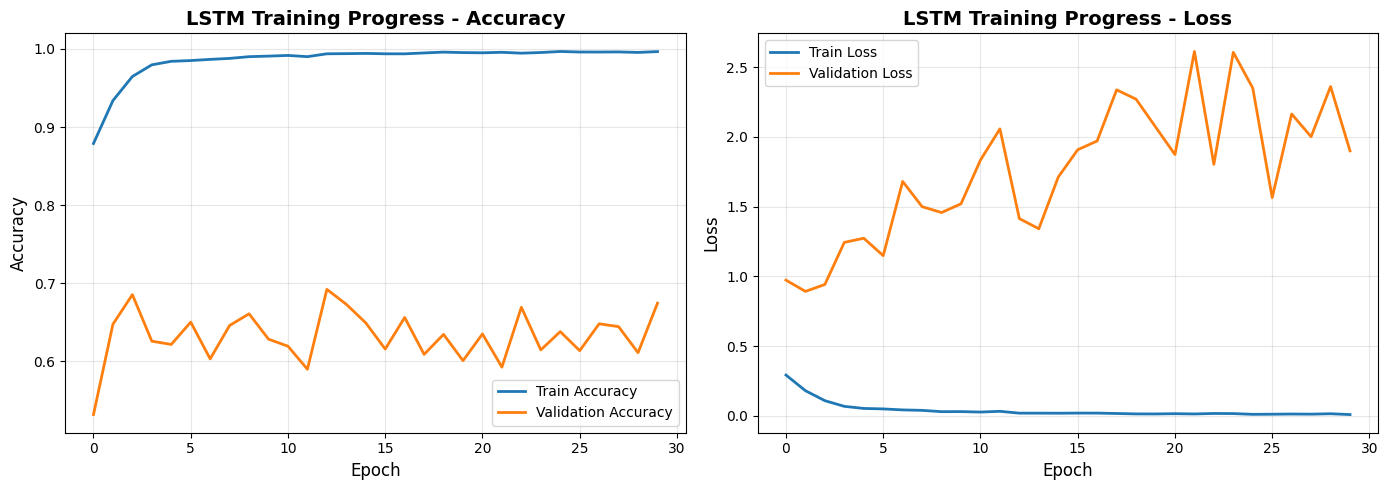

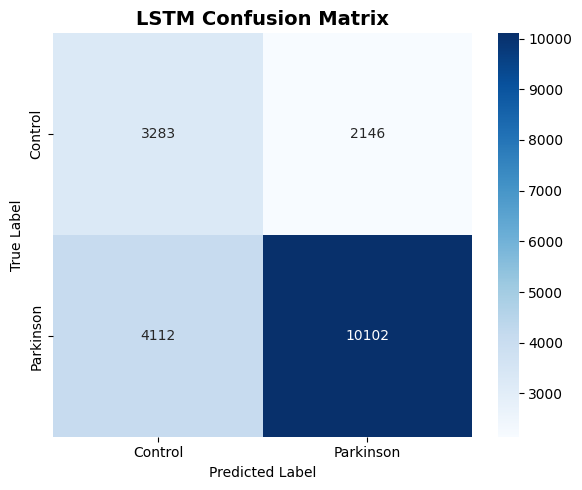


PERFORMANCE COMPARISON (All Deliverables)
Approach                          | Accuracy | F1-Score
------------------------------------------------------------
Random Forest (5.2 - Engineered) | 0.7708   | 0.7281
Fully Connected DNN (5.3 - Raw)  | 0.6729   | 0.6362
LSTM (5.4 - Sequential)          | 0.6814   | 0.6378

✓ DELIVERABLE 5.4 COMPLETE


In [12]:
"""
DELIVERABLE 5.4: Sequence-Based Deep Learning Classification (LSTM)
Dataset: Gait in Parkinson's Disease Database (PhysioNet)
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("DELIVERABLE 5.4: LSTM-BASED SEQUENCE CLASSIFICATION")
print("="*60)

#==============================================================================
# 1. DATA PREPARATION: Convert to Sequential Format
#==============================================================================
print("\n1. Preparing Sequential Data...")

def create_sequences(df, sequence_length=100, step=50):
    """
    Creates sequences from time-series data for LSTM input.

    Args:
        df: Preprocessed dataframe from Deliverable 5.1
        sequence_length: Number of time steps (100 samples = 1 second at 100Hz)
        step: Stride for sliding window (50 = 50% overlap)

    Returns:
        X: 3D array (samples, timesteps, features)
        y: Labels (binary: 0=Control, 1=Parkinson)
        subjects: Subject IDs for proper train/test split
    """
    X_sequences = []
    y_labels = []
    subject_ids = []

    # Select sensor columns (16 force sensors + 2 totals)
    sensor_cols = [col for col in df.columns if col.startswith(('L', 'R', 'total'))]

    # Process each subject separately (critical for medical data)
    for subject, group in df.groupby('subject_id'):
        # Extract sensor data and label
        sensor_data = group[sensor_cols].values
        diagnosis = group['diagnosis'].iloc[0]
        label = 1 if 'Parkinson' in str(diagnosis) or 'Pt' in str(diagnosis) else 0

        # Sliding window to create sequences
        for i in range(0, len(sensor_data) - sequence_length, step):
            sequence = sensor_data[i:i + sequence_length]
            X_sequences.append(sequence)
            y_labels.append(label)
            subject_ids.append(subject)

    return np.array(X_sequences), np.array(y_labels), np.array(subject_ids)

# Generate sequences from processed_data (from Deliverable 5.1)
X_seq, y_seq, subjects = create_sequences(processed_data, sequence_length=100, step=50)

print(f"   Sequential Data Shape: {X_seq.shape}")
print(f"   - Samples: {X_seq.shape[0]}")
print(f"   - Time Steps: {X_seq.shape[1]}")
print(f"   - Features: {X_seq.shape[2]}")
print(f"   - Class Distribution: Control={np.sum(y_seq==0)}, Parkinson={np.sum(y_seq==1)}")

#==============================================================================
# 2. SUBJECT-WISE SPLIT (Scientific Standard)
#==============================================================================
print("\n2. Subject-Wise Train/Test Split...")

unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.3, random_state=42
)

# Create masks
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

# Split data
X_train = X_seq[train_mask]
X_test = X_seq[test_mask]
y_train = y_seq[train_mask]
y_test = y_seq[test_mask]

print(f"   Training: {len(train_subjects)} subjects, {X_train.shape[0]} sequences")
print(f"   Testing: {len(test_subjects)} subjects, {X_test.shape[0]} sequences")

#*******************************************
# 3. FEATURE NORMALIZATION (Per-Feature Scaling)
#*******************************************
print("\n3. Normalizing Features...")

# Reshape to 2D for scaling, then back to 3D
n_samples_train, n_timesteps, n_features = X_train.shape
X_train_reshaped = X_train.reshape(-1, n_features)
X_test_reshaped = X_test.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(n_samples_train, n_timesteps, n_features)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape[0], n_timesteps, n_features)

print("   ✓ Features standardized (mean=0, std=1)")

#*******************************************
# 4. BUILD LSTM MODEL
#*******************************************
print("\n4. Building LSTM Model...")

model = Sequential([
    # LSTM Layer: Captures temporal dependencies in gait patterns
    LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False),

    # Dropout: Regularization to prevent overfitting
    Dropout(0.3),

    # Dense Layer: Feature abstraction
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output Layer: Binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

#*******************************************
# 5. TRAIN MODEL
#*******************************************
print("\n5. Training LSTM Model...")

history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

#*******************************************
# 6. EVALUATE MODEL
#*******************************************
print("\n6. Evaluating Model Performance...")

# Predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*60)
print("LSTM MODEL RESULTS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*60)

#*******************************************
# 7. VISUALIZATIONS
#*******************************************
print("\n7. Generating Visualizations...")

# A. Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('LSTM Training Progress - Accuracy', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('LSTM Training Progress - Loss', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# B. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Control', 'Parkinson'],
            yticklabels=['Control', 'Parkinson'])
plt.title('LSTM Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

#*******************************************
# 8. COMPARATIVE SUMMARY
#*******************************************
print("\n" + "="*60)
print("PERFORMANCE COMPARISON (All Deliverables)")
print("="*60)
print("Approach                          | Accuracy | F1-Score")
print("-" * 60)
print(f"Random Forest (5.2 - Engineered) | 0.7708   | 0.7281")
print(f"Fully Connected DNN (5.3 - Raw)  | 0.6729   | 0.6362")
print(f"LSTM (5.4 - Sequential)          | {accuracy:.4f}   | {f1:.4f}")
print("="*60)

print("\n✓ DELIVERABLE 5.4 COMPLETE")